# 📊 Vasicek Asset Correlation (ρ) Estimation

This notebook estimates the **asset correlation (ρ)** required for the Vasicek single-factor credit portfolio model.

The PD dataset spans **multiple years (2007–2014)**. To capture the effect of different economic conditions, the **observed default rates are first aggregated by year**.

These yearly default rates will then be used to estimate the **systematic asset correlation parameter (ρ)** used in the Vasicek framework.

### Steps

1. Import the prepared PD modelling dataset  
2. Extract and verify the **year variable**  
3. Aggregate **default rates by year**  
4. Use the time series of observed default rates to estimate **asset correlation (ρ)**

The estimated ρ will later be used in the **Vasicek Monte Carlo portfolio simulation**.

In [3]:
# ── Libraries ─────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Load dataset prepared in previous notebook ───────────
df = pd.read_pickle("../data/processed/vasicek_pd_data.pkl")

# ── Basic data check ─────────────────────────────────────
print("Dataset shape:", df.shape)

df.head()

Dataset shape: (230795, 2)


,year,default
0,2011,0
1,2011,1
2,2011,0
3,2011,0
4,2011,0


### Aggregate Observed Default Rates by Year

To estimate the Vasicek asset correlation parameter (ρ), we first compute the **observed default rate for each year**.

The annual default rate is defined as:

Default Rate = Number of Defaults in Year / Total Loans in Year

This produces a **time series of default rates**, which reflects how portfolio credit risk varies across different economic conditions.

These yearly default rates will later be used to estimate the **systematic asset correlation (ρ)** in the Vasicek single-factor model.

In [5]:
# ── Compute observed default rate by year ────────────────
yearly_default_rates = df.groupby('year')['default'].mean().reset_index()

yearly_default_rates.rename(columns={'default': 'default_rate'}, inplace=True)

yearly_default_rates

,year,default_rate
0,2007,0.262023
1,2008,0.207271
2,2009,0.136906
3,2010,0.140062
4,2011,0.163237
5,2012,0.163578
6,2013,0.210295
7,2014,0.210570


In [6]:
# ── Compute summary statistics of yearly default rates ──
mean_default_rate = yearly_default_rates['default_rate'].mean()
variance_default_rate = yearly_default_rates['default_rate'].var()

print("Mean Default Rate:", round(mean_default_rate, 4))
print("Variance of Default Rates:", round(variance_default_rate, 6))

Mean Default Rate: 0.1867
Variance of Default Rates: 0.001852


### Transform Default Rates Using the Vasicek Framework

In the Vasicek single-factor model, portfolio default rates are linked to a
latent systematic risk factor through the inverse standard normal
transformation.

For each year \(t\), the observed default rate \(p_t\) is transformed as:

X_t = Φ⁻¹(p_t)

where Φ⁻¹ is the inverse cumulative distribution function of the standard
normal distribution.

This transformation maps observed default rates into the **systematic risk
factor space**, allowing us to estimate the variability of the common economic
factor driving portfolio defaults.

In [7]:
from scipy.stats import norm

# ── Vasicek transformation ───────────────────────────────
yearly_default_rates['vasicek_factor'] = norm.ppf(yearly_default_rates['default_rate'])

yearly_default_rates

,year,default_rate,vasicek_factor
0,2007,0.262023,-0.637120
1,2008,0.207271,-0.815926
2,2009,0.136906,-1.094327
3,2010,0.140062,-1.080040
4,2011,0.163237,-0.981240
5,2012,0.163578,-0.979858
6,2013,0.210295,-0.805398
7,2014,0.210570,-0.804444


### Estimate Asset Correlation (ρ)

In the Vasicek single-factor model, the transformed default rates represent
realizations of the systematic economic risk factor.

Under the model assumptions, the variance of these transformed values
provides an estimate of the **asset correlation parameter (ρ)**, which
measures the degree to which obligors are jointly influenced by
macroeconomic conditions.

The estimated ρ will later be used in the **Vasicek Monte Carlo portfolio
loss simulation**.

In [8]:
# ── Estimate Vasicek asset correlation (rho) ─────────────
rho_estimate = yearly_default_rates['vasicek_factor'].var()

print("Estimated Asset Correlation (rho):", round(rho_estimate, 4))

Estimated Asset Correlation (rho): 0.0253


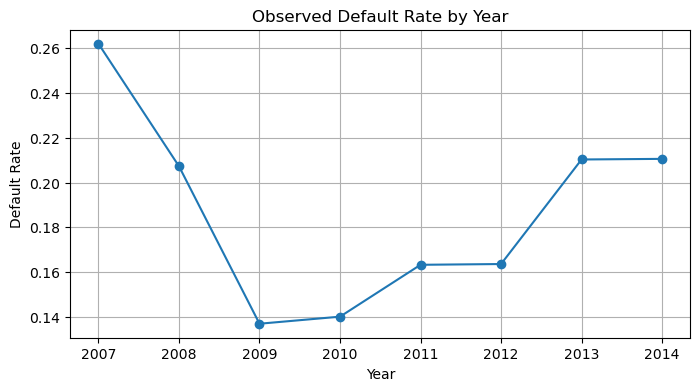

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(yearly_default_rates['year'], yearly_default_rates['default_rate'], marker='o')
plt.title("Observed Default Rate by Year")
plt.xlabel("Year")
plt.ylabel("Default Rate")
plt.grid(True)

plt.show()

### Interpretation

The observed variation in default rates across years reflects changing
macroeconomic conditions affecting borrower credit quality.

Using the Vasicek transformation, this variability leads to an estimated
asset correlation of **ρ ≈ 0.025**, indicating relatively low but
non-zero dependence among borrower defaults typical of retail credit portfolios.
Although the dataset spans the period of the 2008 financial crisis, the observed pattern reflects variation in loan origination cohorts rather than default timing. Therefore, the default rate series captures portfolio risk differences across loan vintages rather than the full macroeconomic shock of the crisis.